In [1]:
!pip install git+https://github.com/mimoralea/gym-bandits#egg=gym-bandits
!pip install git+https://github.com/mimoralea/gym-walk#egg=gym-walk

  Cloning https://github.com/mimoralea/gym-bandits to /tmp/pip-install-v51ueyte/gym-bandits_e37a1080a7e14af1a35f77c752364d45
  Running command git clone --filter=blob:none --quiet https://github.com/mimoralea/gym-bandits /tmp/pip-install-v51ueyte/gym-bandits_e37a1080a7e14af1a35f77c752364d45
  Resolved https://github.com/mimoralea/gym-bandits to commit f4b45d39e59eee3f6377ceb42466749af2cd77bd
  Preparing metadata (setup.py) ... done
  Created wheel for gym-bandits: filename=gym_bandits-0.1-py3-none-any.whl size=5228 sha256=0dbc651564dcab778935ed0207e4f25b60afc2d5832ae31dafe260c2b4402657
  Stored in directory: /tmp/pip-ephem-wheel-cache-8m2ddynr/wheels/e3/80/17/2f221a51a2b9f310bc08097546d94bbcbc646f9374f25da82a
Successfully built gym-bandits
  Cloning https://github.com/mimoralea/gym-walk to /tmp/pip-install-qi1g7jff/gym-walk_e934b76544fa4728a6da5bfce16f012e
  Running command git clone --filter=blob:none --quiet https://github.com/mimoralea/gym-walk /tmp/pip-install-qi1g7jff/gym-walk_e93

In [2]:
import numpy as np
import gymnasium as gym

import warnings ; warnings.filterwarnings('ignore')

from pprint import pprint
# from tqdm import tqdm_notebook as tqdm
from tqdm.notebook import tqdm

from itertools import cycle

import random

np.set_printoptions(suppress=True)
random.seed(123); np.random.seed(123)
SEEDS = (12, 34, 56, 78, 90)



In [3]:
import gym_bandits
import gym
env = gym.make("BanditTenArmedGaussian-v0")
env.reset()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-pack

0

  0%|          | 0/100000 [00:00<?, ?it/s]

(array([    3.,    12.,    53.,   262.,   878.,  2325.,  5274.,  9674.,
        14285., 17550., 17525., 14228.,  9459.,  5115.,  2249.,   810.,
          228.,    60.,     7.,     3.]),
 array([-4.18674501, -3.73252027, -3.27829553, -2.82407078, -2.36984604,
        -1.9156213 , -1.46139655, -1.00717181, -0.55294706, -0.09872232,
         0.35550242,  0.80972717,  1.26395191,  1.71817665,  2.1724014 ,
         2.62662614,  3.08085088,  3.53507563,  3.98930037,  4.44352512,
         4.89774986]),
 <BarContainer object of 20 artists>)

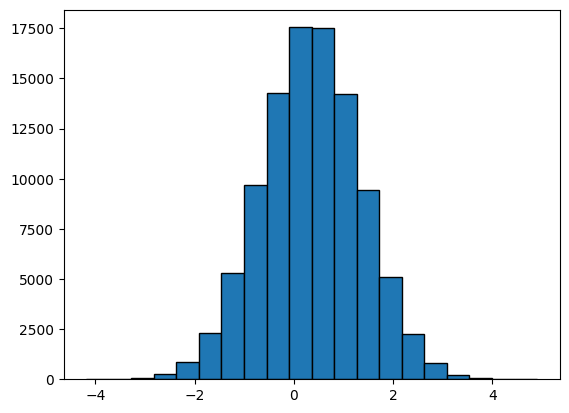

In [5]:
Q = np.zeros((env.action_space.n))
action = np.argmax(Q)

_, reward, _ , _ = env.step(action)
rewards=[]
for i in tqdm( range (100000)):
  _, reward, _ , _ = env.step(action)
  rewards.append(reward)

## distribution of rewards for many iterations

import matplotlib.pyplot as plt

plt.hist(rewards, edgecolor='black', bins=20)

In [6]:
print(env.env.r_dist)
print(env.env.p_dist)

[[0.345584192064786, 1], [0.8216181435011584, 1], [0.33043707618338714, 1], [-1.303157231604361, 1], [0.9053558666731177, 1], [0.4463745723640113, 1], [-0.5369532353602852, 1], [0.5811181041963531, 1], [0.36457239618607573, 1], [0.294132496655526, 1]]
[1 1 1 1 1 1 1 1 1 1]


In [7]:
b10_Vs = []
for seed in SEEDS:
    env_name = 'BanditTenArmedGaussian-v0'
    env = gym.make(env_name, seed=seed) ; env.reset()
    r_dist = np.array(env.env.r_dist)[:,0]
    b10_Q = np.array(env.env.p_dist * r_dist)

    print('10-Armed Bandit environment with seed', seed)
    ## reward always pays out --> so prob of getting reward is always 1
    print('Probability of reward:', env.env.p_dist)
    ## reward values will change as per the seed
    print('Reward:', r_dist)

    print('Q(.):', b10_Q)

    b10_Vs.append(np.max(b10_Q))

    print('V*:', b10_Vs[-1])

    print()
print('Mean V* across all seeds:', np.mean(b10_Vs))

10-Armed Bandit environment with seed 12
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.00682678  1.04614329  0.74158842  0.72395654  1.61877622 -1.20555814
 -0.62695547 -1.32066321 -0.10775251  0.99876366]
Q(.): [-0.00682678  1.04614329  0.74158842  0.72395654  1.61877622 -1.20555814
 -0.62695547 -1.32066321 -0.10775251  0.99876366]
V*: 1.6187762233340763

10-Armed Bandit environment with seed 34
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.03992466 -1.25773672  2.57402319  0.48179798  0.64354662 -0.20792668
  0.05828708  0.33674264  0.19510709 -0.60931449]
Q(.): [-0.03992466 -1.25773672  2.57402319  0.48179798  0.64354662 -0.20792668
  0.05828708  0.33674264  0.19510709 -0.60931449]
V*: 2.574023189963745

10-Armed Bandit environment with seed 56
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.84994072  0.32194085  1.78904286  0.8793392   0.37159282  1.48769378
  0.72866553  2.08124873 -1.33726808  0.12535155]
Q(.): [-0.84994072  0.32194085  1.78904286  

## Pure exploitation


In [8]:
def pure_exploit(env, n_episodes=5000):
  Q =np.zeros((env.action_space.n))
  N =np.zeros((env.action_space.n))

  ## storing estimates for each episodes
  Qe = np.empty((n_episodes, env.action_space.n))
  returns = np.empty(n_episodes)
  actions = np.empty(n_episodes, dtype=int)

  name = 'pure_exploitation'
  for e in tqdm(range(n_episodes), desc = "Episodes for : "+name, leave = False):
    action = np.argmax(Q)
    _, reward, _ , _ = env.step(action)
    N[action] +=1
    # print(N[action])

    Q[action] = Q[action] +(reward - Q[action])/N[action]
    # print(Q[action])

    ## storing data in the table
    Qe[e] = Q
    returns[e] =reward
    actions[e] = action

  return name, returns, Qe, actions



In [11]:
name, returns, Qe, actions= pure_exploit(env)

Episodes for : pure_exploitation:   0%|          | 0/5000 [00:00<?, ?it/s]

(array([  11.,   65.,  303.,  802., 1337., 1270.,  804.,  338.,   57.,
          13.]),
 array([-1.78861321, -1.06994312, -0.35127302,  0.36739707,  1.08606716,
         1.80473725,  2.52340734,  3.24207743,  3.96074753,  4.67941762,
         5.39808771]),
 <BarContainer object of 10 artists>)

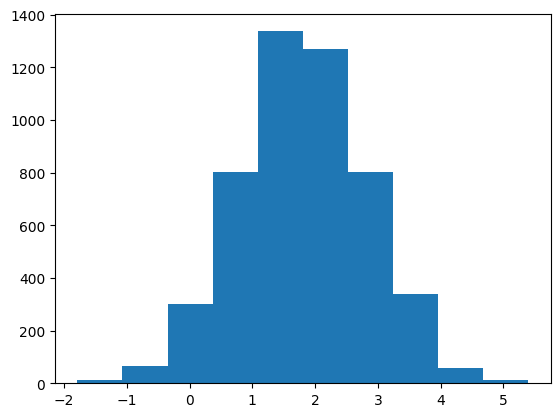

In [12]:
plt.hist(returns)